2021년 데이터만 있음
용답 - 2호선
신답 - 2호선 (성수지선)
신설동 - 1호선, 2호선, 우이신설선
도림천 - 2호선 (신정지선)
양천구청 - 2호선 (신정지선)
신정네거리 - 2호선 (신정지선)
용두 - 2호선 (성수지선)
까치산 - 2호선, 5호선

둔촌동 - 5호선
올림픽공원(한국체대) - 5호선, 9호선
방이 - 5호선
오금 - 3호선, 5호선
개롱 - 5호선
거여 - 5호선
마천 - 5호선 (마천지선)


하나의 종류의 데이터 즉 같은 라인,시간,평일,방향의 다른년도 데이터 각각 8개 학습하기에 너무나 부족한 데이터

**여기부터 전처리 완료된 통합 코드**

In [19]:
import pandas as pd
import requests

# API 설정
page = 1
perPage = 1667
merged_data = {}
api = [
    'uddi:70e3a3d3-0872-4828-8234-f0bca459b44f',  # 2019
    'uddi:99771417-a036-46f1-8ad5-8edf4591c2ee',  # 2020
    'uddi:b3803d43-ffe3-4d17-9024-fd6cfa37c284',  # 2021
    'uddi:75461a18-17a3-42fe-9322-a51148003b69',  # 2022
    'uddi:e477f1d9-2c3a-4dc8-b147-a55584583fa2',  # 2023
    'uddi:c87b6af0-0ef7-4182-b172-fd2680a79d6f',  # 2024/03
    'uddi:9aff0ee6-26e7-42c4-af0c-84bf31680ca9',  # 2024/06
    'uddi:da7cd08f-94f0-4dba-b33d-d02dcb35b57b'   # 2024/09
]

# API 데이터 요청
service_key = '9bi5h25Oa1d6yB2qd+7vNhE7qWLhgJvDSr4dTv6vhlZ3rvlpNTbs6NZv/B+R/CvFLssD7Flh+jSDAYydOoaRfQ=='
for uddi in api:
    url = f'https://api.odcloud.kr/api/15071311/v1/{uddi}'
    params = {'serviceKey': service_key, 'returnType': 'XML', 'page': page, 'perPage': perPage}
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        merged_data[uddi] = response.text
    except requests.RequestException as e:
        print(f"API 요청 실패: {uddi}, 에러: {e}")

In [28]:
import xml.etree.ElementTree as ET

# XML 데이터 파싱
def parsing(data, year):
    xml_obj = ET.fromstring(data)
    rows = []

    # XML 데이터를 딕셔너리로 변환
    for row in xml_obj.findall('.//item'):
        row_data = {}
        for col in row.findall('.//col'):
            if col.attrib['name'] == "조사일자":
                row_data['요일구분'] = col.text  # 조사일자 -> 요일구분
            elif col.attrib['name'] == "구분":
                row_data['상하구분'] = col.text  # 구분 -> 상하구분
            elif col.attrib['name'] == "출발역": # 출발역 -> 역명
                row_data['역명'] = col.text
            else:
                row_data[col.attrib['name']] = col.text  # 그 외의 경우 일반적으로 처리
        if row_data:
            rows.append(row_data)

    df = pd.DataFrame(rows)

    # 기본 매핑
    column_mapping = {
        '년도': 'year', '호선': 'line', '상하구분': 'direction',
        '역명': 'station_name', '역번호': 'station_id', '요일구분': 'day_type'
    }


    # 기본 컬럼명 매핑
    df = df.rename(columns=column_mapping)

    # 년도 추가
    df['year'] = year

    # '연번' 컬럼 제거
    if '연번' in df.columns:
        df = df.drop(columns=['연번'])

    return df

# 각 년도의 데이터 병합
years = [2020, 2021, 2022, 2023, 202403, 202406, 202409]
final_df = pd.concat([parsing(merged_data[uddi], year) for uddi, year in zip(api, years)], ignore_index=True)

# 데이터 변환 및 필터링
final_df['line'] = final_df['line'].replace({'13': '2', '14': '2', '15': '5'})  # 라인 수정
final_df = final_df[~final_df['line'].isin(['성수지선', '신정지선'])]  # 특정 라인 제거
final_df['line'] = final_df['line'].replace({f'{i}호선': str(i) for i in range(1, 9)})

# 데이터를 '시간'과 '혼잡도'로 변형
final_df = pd.melt(final_df,
                      id_vars=['year', 'line', 'direction', 'station_name', 'station_id', 'day_type'],
                      var_name='time',
                      value_name='congestion')

In [29]:
#시간대 매핑 수치형 데이터 변환 new
def convert_time_to_float(time_str):
    hour, minute = map(int, time_str[:-1].split('시'))
    minute = minute / 60  # 분을 시간 단위로 변환
    if hour == 00:
      hour = 24.0
    return hour + minute

final_df['time_float'] = final_df['time'].apply(convert_time_to_float)

# 2. 정규화 (0~1)
min_time = 5.5  # 시작 시간 (5시 30분)
max_time = 24.5  # 종료 시간 (24시 30분)
final_df['time_normalized'] = (final_df['time_float'] - min_time) / (max_time - min_time)


In [30]:
# 데이터 변환 및 필터링
final_df['day_type'] = final_df['day_type'].replace({'평일': '평일', '토요일': '공휴일', '일요일': '공휴일'})
final_df['direction'] = final_df['direction'].replace({'내선': '상선', '외선':'하선'})
final_df['line'] = final_df['line'].replace({'13': '2', '14': '2', '15': '5'})  # 라인 수정
final_df = final_df[~final_df['line'].isin(['성수지선', '신정지선'])]  # 특정 라인 제거
final_df['line'] = final_df['line'].replace({f'{i}호선': str(i) for i in range(1, 9)})

final_df['congestion'] = final_df['congestion'].fillna(0)

# 기존 station_name과 station_id가 있는 DataFrame을 기준으로 매핑 생성
station_mapping = final_df.dropna(subset=['station_name']).set_index('station_id')['station_name'].to_dict()

# station_id를 기준으로 NaN 값을 station_name으로 채우기
final_df['station_name'] = final_df['station_name'].fillna(final_df['station_id'].map(station_mapping))
# 특정 ID 매핑
station_name_mapping = {'405': '전접', '406': '오남', '408': '별내별가람'}

<ipython-input-30-5dc31943a535>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['congestion'] = final_df['congestion'].astype('float32')


In [ ]:
# 데이터 타입 지정

final_df = final_df[~final_df['station_id'].isin(['2828', '9001', '9002', '9003', '9005', '9006'])]
final_df['congestion'] = final_df['congestion'].astype('float32')
final_df['station_id'] = final_df['station_id'].astype('int32')
final_df['year'] = final_df['year'].astype('int32')
final_df['line'] = final_df['line'].astype('int32')
final_df['direction'] = final_df['direction'].map({'상선': True, '하선': False})
final_df['day_type'] = final_df['day_type'].map({'평일': True, '공휴일': False})
final_df['direction'] = final_df['direction'].astype('boolean')
final_df['day_type'] = final_df['day_type'].astype('boolean')

In [ ]:
# 각 호선 데이터 CSV로 저장
#필요한 컬럼만 선택
data = final_df[['line','direction','day_type','station_id','time_normalized','congestion']]
line_data = {}
for line in range(1, 9):
    line_data[f'{line}'] = data.loc[final_df['line'] == line]  # 각 호선 데이터 필터링
    line_data[f'{line}'].to_csv(f'line_{line}.csv', index=False)  # 각 호선에 대해 CSV 파일로 저장

In [37]:
origin_mergeed = data.to_csv('merged_data.csv', index=False)

In [ ]:
#######################################################################################################################
#전처리 완료됨

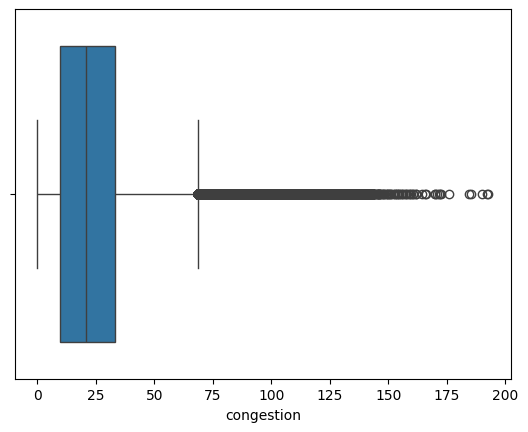

count    471787.000000
mean         23.401157
std          18.549749
min           0.000000
25%           9.800000
50%          20.700001
75%          33.299999
max         192.800003
Name: congestion, dtype: float64


In [39]:
sns.boxplot(x=data['congestion'])
plt.show()

print(data['congestion'].describe()
#출퇴근 시간과 아닌시간의 혼잡도 차이가 커서 모델의 예측 편향도가 높은듯

In [31]:
final_df.info()
#year, station_name은 필요x
#day_type 을 0 평일 1 공휴일로 원핫인코딩? 부울형으로
#direction 을 상행 하행 T F 내선 외선 T F
#time 을 수치형 데이터 0~1로 바꿀까? 5시반 부터 12시 반까지 현재는 5.5 ~ 23.5 ~ 0.0, 0.5 로 설정됨
#congestion 0~34~150
#5호선 ~ 8선은 station_id 천의자리가 2로 바뀜 2522면 522번이 실제 id값

<class 'pandas.core.frame.DataFrame'>
Index: 471787 entries, 0 to 476091
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   year             471787 non-null  int32  
 1   line             471787 non-null  int32  
 2   direction        471787 non-null  boolean
 3   station_name     471787 non-null  object 
 4   station_id       471787 non-null  int32  
 5   day_type         471787 non-null  boolean
 6   time             471787 non-null  object 
 7   congestion       471787 non-null  float32
 8   time_float       471787 non-null  float64
 9   time_normalized  471787 non-null  float64
dtypes: boolean(2), float32(1), float64(2), int32(3), object(2)
memory usage: 27.0+ MB


In [32]:
print(final_df.isnull().sum())

year               0
line               0
direction          0
station_name       0
station_id         0
day_type           0
time               0
congestion         0
time_float         0
time_normalized    0
dtype: int64


In [46]:
final_df.head()

,year,line,direction,station_name,station_id,day_type,time,congestion,time_float,time_normalized
0,2020,1,True,서울역,150,True,14시30분,29.600000,14.5,0.473684
1,2020,1,False,서울역,150,True,14시30분,30.000000,14.5,0.473684
2,2020,1,True,시청,151,True,14시30분,30.400000,14.5,0.473684
3,2020,1,False,시청,151,True,14시30분,35.400002,14.5,0.473684
4,2020,1,True,종각,152,True,14시30분,30.400000,14.5,0.473684


In [ ]:
#!pip install lightgbm==3.3.2
#!pip install xgboost==1.7.2
!pip install keras==3.2.0
!pip install tensorflow==2.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.9 MB/s eta 0:00:00
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.5.0
    Uninstalling lightgbm-4.5.0:
      Successfully uninstalled lightgbm-4.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 MB 4.9 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.2
    Uninstalling xgboost-2.1.2:
      Successfully uninstalled xgboost-2.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.1 MB/s eta 0:00:00
   ━━━

In [ ]:
# 역번호로 역명 찾기 함수
def get_station_name(station_number):
    result = line_data['1'].loc[line_data['1']['station_id'] == station_number, 'station_name']
    if not result.empty:
        return result.values[0]  # 역명 반환
    else:
        return "해당 역번호에 대한 역명이 없습니다."
        # 역명으로 역번호 찾기 함수
def get_station_number(station_name):
    result = line_data['1'].loc[line_data['1']['station_name'] == station_name, 'station_id']
    if not result.empty:
        return result.values[0]  # 역번호 반환
    else:
        return "해당 역명에 대한 역번호가 없습니다."

In [ ]:
print(get_station_number("서울"))
print(get_station_name("2555"))

해당 역명에 대한 역번호가 없습니다.
해당 역번호에 대한 역명이 없습니다.


In [ ]:
for line in range(1, 9):
  print(f"--- {line}호선 데이터 ---")
  print(line_data[f'{line}'])
    #print("\n")

--- 1호선 데이터 ---
          year  line direction  station_name  station_id day_type time  \
0         2020     1        상선           150         150       평일   11   
1         2020     1        하선           150         150       평일   11   
2         2020     1        상선           151         151       평일   11   
3         2020     1        하선           151         151       평일   11   
4         2020     1        상선           152         152       평일   11   
...        ...   ...       ...           ...         ...      ...  ...   
452328  202409     1        하선           152         152      일요일  6.5   
452329  202409     1        상선           151         151      일요일  6.5   
452330  202409     1        하선           151         151      일요일  6.5   
452331  202409     1        상선           150         150      일요일  6.5   
452332  202409     1        하선           150         150      일요일  6.5   

        congestion  
0        45.900002  
1        20.400000  
2        41.099998  
3        19

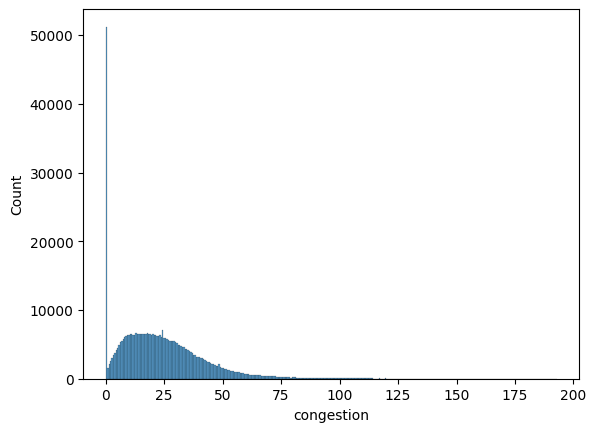

In [40]:
# 혼잡도 분포도 승객과좌석 일치시 34%
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#sns.histplot(data=line_data['1'], x='congestion')
sns.histplot(final_df, x='congestion')

plt.show()
#결측값이 0이 되기 때문에 표본을 크게 왜곡함
#결측값이 혼잡도가 없는 시간대에 발생했다면 0으로 아닌경우엔 중앙값으로 바꾸어야 함
#최소값 0% , 34% 중간값, 150% 최댓값
#평일 TRUE , 상행 TRUE

In [ ]:
# 'station_data['1']'에서 가장 큰 'congestion' 값을 찾기
max_congestion_row = line_data['1'].loc[line_data['1']['congestion'].idxmax()]
count_over60_congestion_row = line_data['1'][line_data['1']['congestion'] > 60]['congestion'].count()
# 최댓값 출력
print("가장 큰 혼잡도:\n", max_congestion_row['congestion'])
print("60 이상의 혼잡도:\n",)
print("해당 행의 정보:\n", max_congestion_row)

가장 큰 혼잡도:
 123.4
60 이상의 혼잡도:

해당 행의 정보:
 year                202409
line                     1
direction               하선
station_name           150
station_id             150
day_type                평일
time                    18
congestion      123.400002
Name: 381548, dtype: object


In [53]:
# 학습없이 데이터의 중앙값을 통한 출력
data = final_df
def get_median_congestion(direction, day_type, time, station_name, line):
    filtered_data = data[
        (data['direction'] == direction) &
        (data['day_type'] == day_type) &
        (data['time'] == time) &
        (data['station_name'] == station_name) &
        (data['line'] == line)
    ]
    if not filtered_data.empty:
        return filtered_data['congestion'].median()
    else:
        return "해당 조건의 데이터가 없습니다."

# 입력 예시
direction = True
day_type = True
time = "8시00분" #8시30분 15시30분 8시 00분
station_name = "서울역"
line = 1

result = get_median_congestion(direction, day_type, time, station_name, line)
print("예측된 혼잡률:", result)

예측된 혼잡률: 69.0999984741211


In [54]:
data.to_csv('merged_data.csv', index=False)

In [ ]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow import keras
from tensorflow.keras import layers

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


케라스모델 예시

In [ ]:
data = line_data['1']
# 데이터를 독립변수(X)와 종속변수(y)로 나눕니다.
X = data[['direction', 'station_id', 'day_type', 'time', 'congestion']]
y = data['congestion']

# 데이터를 학습, 테스트 데이터로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 범주형 열에 OneHot 인코딩을 적용
categorical_features = ['direction', 'station_id', 'day_type', 'time', 'congestion']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[('cat', categorical_transformer, categorical_features)],
    remainder='passthrough')  # 나머지 변수를 유지

# One-hot 인코딩된 데이터로 변환
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
#케라스모델 학습
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# station_data['1']에서 데이터를 불러옵니다.
data = line_data['1']

# 'direction', 'station_id', 'day_type', 'time', 'congestion' 컬럼만 선택합니다.
data = data[['direction', 'station_id', 'day_type', 'time', 'congestion']]

# 'direction'과 'day_type'에 대한 원-핫 인코딩
data = pd.get_dummies(data, columns=['direction', 'day_type','time'])

# 특성과 타겟을 나눕니다.
X = data.drop('congestion', axis=1)
y = data['congestion']

# X에 대해서 추가적으로 원-핫 인코딩을 진행합니다.
X = pd.get_dummies(X)

# 데이터 타입을 float32로 변환하여 TensorFlow에 맞게 처리
X = X.astype('float32')
y = y.astype('float32')

# 데이터를 학습용과 테스트용으로 분리합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 신경망 모델을 정의합니다.
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X.shape[1]))  # 첫 번째 은닉층
model.add(Dense(32, activation='relu'))  # 두 번째 은닉층
model.add(Dense(1))  # 출력층

# 모델을 컴파일합니다.
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy')

# 모델을 학습시킵니다.
model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test))

# 학습된 모델을 TFLite 형식으로 변환합니다.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# 변환된 TFLite 모델을 파일로 저장합니다.
with open('subway_congestion_model.tflite', 'wb') as f:
    f.write(tflite_model)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/losses/losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.6451e-06 - val_loss: 2.6650e-06
Epoch 2/100


/usr/local/lib/python3.10/dist-packages/keras/src/losses/losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6527e-06 - val_loss: 2.6650e-06
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6606e-06 - val_loss: 2.6650e-06
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6521e-06 - val_loss: 2.6650e-06
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6389e-06 - val_loss: 2.6650e-06
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6673e-06 - val_loss: 2.6650e-06
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6611e-06 - val_loss: 2.6650e-06
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6444e-06 - val_loss: 2.6650e-06
Epoch 9/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6164e-06 - val_loss: 2.6650e-06
Epoch 10/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6587e-06 - val_loss: 2.6650e-06
Epoch 11/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6417e-06 - val_loss: 2.6650e-06
Epoch 12/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss

선형 회귀 모델: 입력 변수와 출력 변수 간의 선형 관계를 모델링하는 간단한 모델입니다.
의사 결정 트리 회귀 모델: 복잡한 비선형 관계를 모델링할 수 있는 트리 기반 모델입니다.
랜덤 포레스트 회귀 모델: 여러 개의 의사 결정 트리를 결합하여 더 강력한 예측 성능을 제공하는 앙상블 모델입니다.
다층 퍼셉트론(MLP) 회귀 모델: 여러 은닉층을 가진 심층 신경망 모델로, 복잡한 비선형 관계를 학습할 수 있습니다.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Linear Regression
linear_model = Sequential()
linear_model.add(Dense(1, input_dim=X.shape[1]))
linear_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Decision Tree Regression
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.tree import DecisionTreeRegressor
tree_model = KerasRegressor(model=DecisionTreeRegressor())

# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
forest_model = KerasRegressor(model=RandomForestRegressor())

# Multi-Layer Perceptron (MLP) Regression
mlp_model = Sequential()
mlp_model.add(Dense(64, activation='relu', input_dim=X.shape[1], kernel_regularizer=l2(0.01)))
mlp_model.add(Dropout(0.2))
mlp_model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
mlp_model.add(Dropout(0.2))
mlp_model.add(Dense(1))
mlp_model.compile(optimizer=Adam(), loss='mean_squared_error')

은닉층의 유닛 수 (units_1, units_2)
학습률 (learning_rate)
L2 정규화 강도 (l2_reg)

GridSearchCV를 사용하여 이 4개의 하이퍼파라미터 조합에 대해 5 fold 교차 검증을 수행하고, 가장 좋은 성능을 보이는 하이퍼파라미터 조합을 찾습니다.
이렇게 하이퍼파라미터를 튜닝하면 다음과 같은 효과를 얻을 수 있습니다:

은닉층의 유닛 수를 조절하여 모델의 복잡도를 조절할 수 있습니다. 이를 통해 과적합 및 과소적합 문제를 해결할 수 있습니다.
학습률을 조절하여 모델의 수렴 속도와 수렴 정도를 제어할 수 있습니다.
L2 정규화를 통해 모델의 복잡도를 제어하고 과적합을 방지할 수 있습니다.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path='subway_congestion_model.tflite')
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Station ID 설정
station_id = 150

# 시간 범위 설정
times = np.arange(5.5, 24, 0.5)  # 5:30부터 30분 단위
congestion_levels = []

# 학습 데이터에서 컬럼 순서 로드
X_train_columns = pd.read_csv('X_train_columns.csv')['columns'].tolist()

for time in times:
    # 예측용 데이터프레임 생성
    sample_data_df = pd.DataFrame({
        'direction': ['상선'],
        'station_id': [station_id],
        'day_type': ['휴일'],
        'time': [time]
    })

    # 범주형 처리 및 One-Hot Encoding
    sample_data_df['time'] = sample_data_df['time'].astype(str)
    sample_data_df = pd.get_dummies(sample_data_df, columns=['direction', 'day_type', 'time'])

    # 컬럼 누락 처리 및 정렬
    for col in X_train_columns:
        if col not in sample_data_df.columns:
            sample_data_df[col] = 0.0
    sample_data_df = sample_data_df[X_train_columns]

    # 데이터 변환
    sample_data = sample_data_df.values.astype(np.float32).reshape(1, -1)

    # TFLite 모델에 입력
    interpreter.set_tensor(input_details[0]['index'], sample_data)
    interpreter.invoke()

    # 예측값 저장
    output_data = interpreter.get_tensor(output_details[0]['index'])
    congestion_levels.append(output_data[0][0])


# 결과 시각화
plt.figure(figsize=(12, 6))
time_labels = [f'{int(t)}:{int((t % 1) * 60):02d}' for t in times]
plt.plot(times, congestion_levels, marker='o', color='b', label='Predicted Congestion Level')
plt.xlabel('Time')
plt.ylabel('Congestion Level')
plt.title(f'Station {station_id} Congestion Levels by Time')
plt.xticks(times, labels=time_labels, rotation=45)
plt.legend()
plt.grid()
plt.show()

ValueError: Cannot set tensor: Dimension mismatch. Got 4 but expected 43 for dimension 1 of input 0.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 데이터 준비
X = data[['direction', 'station_id', 'day_type', 'time']]
y = data['congestion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
pd.DataFrame({'columns': X_train.columns}).to_csv('X_train_columns.csv', index=False)

# 전처리
categorical_features = ['direction', 'day_type', 'time']
numerical_features = ['station_id']

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
    ]
)

# 데이터 변환
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# 모델 정의
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=X_train_transformed.shape[1]),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1)
])

# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# 모델 훈련
model.fit(X_train_transformed, y_train, epochs=20, batch_size=32, validation_data=(X_test_transformed, y_test))

# 모델 평가
loss, mae = model.evaluate(X_test_transformed, y_test)
print(f'Test Loss: {loss}, Test MAE: {mae}')
# 학습된 모델을 TFLite 형식으로 변환합니다.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# 변환된 TFLite 모델을 파일로 저장합니다.
with open('subway_congestion_model.tflite', 'wb') as f:
    f.write(tflite_model)
pd.DataFrame({'columns': X_train.columns}).to_csv('X_train_columns.csv', index=False)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 351.2670 - mae: 14.4143 - val_loss: 100.7708 - val_mae: 7.4673
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 116.2098 - mae: 7.9194 - val_loss: 92.5653 - val_mae: 6.8490
Epoch 3/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 102.2648 - mae: 7.3645 - val_loss: 82.6428 - val_mae: 6.4545
Epoch 4/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 93.3926 - mae: 6.9916 - val_loss: 74.6522 - val_mae: 6.1563
Epoch 5/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 88.3262 - mae: 6.7821 - val_loss: 69.3469 - val_mae: 5.8820
Epoch 6/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 80.1513 - mae: 6.4289 - val_loss: 64.2210 - val_mae: 5.6696
Epoch 7/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 79.4646 - mae: 6.2833 - val_loss: 57.9929 - val_mae: 5.4111
Epoch 8/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 73.2497 - mae: 6.1322 - val_loss: 53.1705 - val_mae: 5.2059
Epoch 9/20
359/359 ━━━━━━━━━━━━━━━━

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 365.6547 - mae: 14.5944 - val_loss: 95.7157 - val_mae: 6.9054
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 100.9786 - mae: 7.3002 - val_loss: 80.3076 - val_mae: 6.2358
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 92.3558 - mae: 6.8881 - val_loss: 66.8391 - val_mae: 5.7206
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 76.3555 - mae: 6.2988 - val_loss: 58.4460 - val_mae: 5.4520
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 69.1993 - mae: 5.9949 - val_loss: 53.0092 - val_mae: 5.1567
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 69.9611 - mae: 5.9414 - val_loss: 49.8580 - val_mae: 5.0356
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 66.2263 - mae: 5.7531 - val_loss: 46.4107 - val_mae: 4.7492
Epoch 8/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 59.1057 - mae: 5.4653 - val_loss: 43.5302 - val_mae: 4.6524
Epoch 9/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

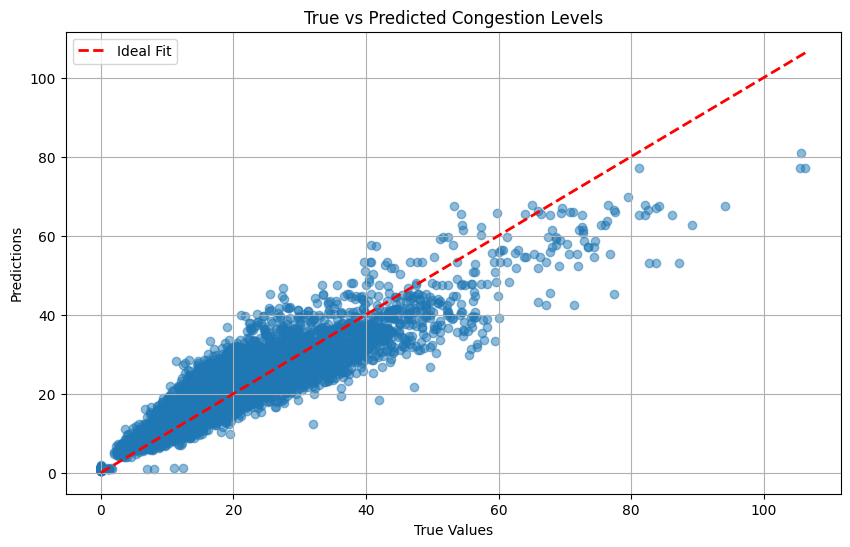

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 데이터 준비
X = data[['direction', 'station_id', 'day_type', 'time']]
y = data['congestion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 전처리
categorical_features = ['direction', 'day_type', 'time']
numerical_features = ['station_id']

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
    ]
)

# 데이터 변환
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# 모델 정의
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=X_train_transformed.shape[1]),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1)
])

# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# EarlyStopping 콜백 정의
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 모델 훈련
model.fit(X_train_transformed, y_train,
          epochs=50,
          batch_size=32,
          validation_data=(X_test_transformed, y_test),
          callbacks=[early_stopping])

# 모델 평가
loss, mae = model.evaluate(X_test_transformed, y_test)
y_pred = model.predict(X_test_transformed).flatten()
r2 = r2_score(y_test, y_pred)

print(f'Test Loss: {loss}, Test MAE: {mae}, R^2 Score: {r2}')

# TFLite 모델 변환 및 저장
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('subway_congestion_model.tflite', 'wb') as f:
    f.write(tflite_model)

pd.DataFrame({'columns': X_train.columns}).to_csv('X_train_columns.csv', index=False)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Congestion Levels')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

# 예시 샘플 데이터 준비
station_id = 150  # 예시: 역 번호 150
direction = '상선'  # 예시: 상선 방향
day_type = '휴일'   # 예시: 휴일
time = 8.5          # 예시: 8:30

# 예측을 위한 샘플 데이터 준비
sample_data_df = pd.DataFrame({
    'direction': [direction],
    'station_id': [station_id],
    'day_type': [day_type],
    'time': [time]
})

# NaN 값 처리 (필요한 경우)
sample_data_df = sample_data_df.fillna('unknown')  # NaN을 'unknown'으로 대체

# 데이터 유형 강제 변환 (필요한 경우)
sample_data_df['station_id'] = sample_data_df['station_id'].astype(int)

# TFLite 모델 로드
interpreter = tf.lite.Interpreter(model_path="subway_congestion_model.tflite")
interpreter.allocate_tensors()

# 샘플 데이터를 전처리
sample_data_transformed = preprocessor.transform(sample_data_df)

# 모델 입력 텐서 가져오기
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 입력 데이터 형상에 맞게 변환
input_data = np.array(sample_data_transformed, dtype=np.float32)

# 예측 수행
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# 예측 결과 가져오기
output_data = interpreter.get_tensor(output_details[0]['index'])
y_pred = output_data[0][0]

# 예측 결과 출력
print(f'예측된 혼잡도: {y_pred}')


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
# ColumnTransformer에서 원핫 인코딩된 특성들의 이름을 확인
cat_columns = preprocessor.transformers_[0][1].named_steps['onehot'].get_feature_names_out(input_features=categorical_features)

# 전체 특성 이름 확인
all_columns = list(cat_columns) + numerical_features
print(all_columns)

['direction_상선', 'direction_하선', 'day_type_공휴일', 'day_type_일요일', 'day_type_토요일', 'day_type_평일', 'time_0', 'time_0.5', 'time_5.5', 'time_6', 'time_6.5', 'time_7', 'time_7.5', 'time_8', 'time_8.5', 'time_9', 'time_9.5', 'time_10', 'time_10.5', 'time_11', 'time_11.5', 'time_12', 'time_12.5', 'time_13', 'time_13.5', 'time_14', 'time_14.5', 'time_15', 'time_15.5', 'time_16', 'time_16.5', 'time_17', 'time_17.5', 'time_18', 'time_18.5', 'time_19', 'time_19.5', 'time_20', 'time_20.5', 'time_21', 'time_21.5', 'time_22', 'time_22.5', 'time_23', 'time_23.5', 'station_id']


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# TFLite 모델 로드
interpreter = tf.lite.Interpreter(model_path='subway_congestion_model.tflite')
interpreter.allocate_tensors()

# 입력과 출력 텐서 정보
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 예측할 데이터 설정
station_id = 150  # 예시: 역 번호 150
direction = '상선'  # 예시: 상선 방향
day_type = '휴일'   # 예시: 휴일
time = 8.5          # 예시: 8:30

# 예측을 위한 샘플 데이터 준비
sample_data_df = pd.DataFrame({
    'direction': [direction],
    'station_id': [station_id],
    'day_type': [day_type],
    'time': [time]
})

# 전처리 - OneHot Encoding 적용 (훈련 시 사용한 컬럼의 값을 동일하게 처리)
categorical_features = ['direction', 'day_type', 'time']
# OneHotEncoder 준비
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(sample_data_df[categorical_features])

# 수치형 특성 (station_id)는 표준화 필요
scaler = StandardScaler()
scaled_station_id = scaler.fit_transform(sample_data_df[['station_id']])

# 새로운 데이터를 통합하여 최종 특성 벡터 생성
final_data = np.hstack([encoded_features, scaled_station_id])

# 입력 텐서에 맞게 크기 변환
final_data = final_data.astype(np.float32)

# 텐서로 입력 설정
interpreter.set_tensor(input_details[0]['index'], final_data)

# 추론 실행
interpreter.invoke()

# 예측 결과 가져오기
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_congestion = output_data[0][0]

print(f"Predicted congestion for station {station_id}, direction {direction}, day_type {day_type}, time {time}: {predicted_congestion}")


ValueError: Cannot set tensor: Dimension mismatch. Got 4 but expected 46 for dimension 1 of input 0.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# TFLite 모델 로드
interpreter = tf.lite.Interpreter(model_path='subway_congestion_model.tflite')
interpreter.allocate_tensors()

# 입력 및 출력 텐서 정보
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 특정 역 및 변수 설정
station_id = 150  # 예: 특정 역번호

# 하루 동안 시간별 혼잡도 예측
times = np.arange(5.5, 24, 0.5)  # 5:30부터 30분 단위로 예측
congestion_levels = []

# 예측을 위한 데이터 준비
for time in times:
    # 샘플 데이터를 DataFrame으로 생성
    sample_data_df = pd.DataFrame({
        'direction': ['상선'],  # 실제 방향 값으로 교체
        'station_id': [station_id],
        'day_type': ['휴일'],    # 실제 day_type 값으로 교체
        'time': [time]
    })

    # 훈련 시 사용한 전처리 적용
    sample_data_df = pd.get_dummies(sample_data_df, columns=['direction', 'day_type'])

    # 전처리 후 훈련 데이터와 동일한 특성 순서 맞추기
    for col in X_train.columns:
        if col not in sample_data_df.columns:
            sample_data_df[col] = 0.0  # 누락된 컬럼을 0으로 채움

    # 열 순서를 훈련 데이터와 동일하게 정렬
    sample_data_df = sample_data_df[X_train.columns]

    # NumPy 배열로 변환 후 float32로 설정
    sample_data = sample_data_df.values.astype(np.float32)

    # 입력 텐서에 데이터 설정
    interpreter.set_tensor(input_details[0]['index'], sample_data)

    # 예측 실행
    interpreter.invoke()

    # 예측 결과 가져오기
    output_data = interpreter.get_tensor(output_details[0]['index'])
    congestion_levels.append(output_data[0][0])  # 예측된 혼잡도 저장

# 시간별 혼잡도 시각화
plt.figure(figsize=(12, 6))
plt.plot(times, congestion_levels, marker='o', color='b', label='Predicted Congestion Level')
plt.xlabel('Time')
plt.ylabel('Congestion Level')
plt.title(f'Station {station_id} Congestion Levels by Time')
plt.xticks(np.arange(5.5, 24, 1), labels=[f'{int(t)}:{int((t % 1) * 60):02d}' for t in np.arange(5.5, 24, 1)], rotation=45)
plt.legend()
plt.grid()
plt.show()


ValueError: Cannot set tensor: Dimension mismatch. Got 4 but expected 46 for dimension 1 of input 0.

In [ ]:
# station_id와 station_name 중복 없이 출력
station_mapping = line_data['1'][['station_id', 'station_name']].drop_duplicates()

# 결과 출력
print(station_mapping)

    station_id station_name
0          150          서울역
2          151           시청
4          152           종각
6          153         종로3가
8          154         종로5가
10         155          동대문
12         156          신설동
14         157          제기동
16         158          청량리
18         159          동묘앞


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path='subway_congestion_model.tflite')
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

station_id = 201
time = 9

# Create a DataFrame for the sample data
sample_data_df = pd.DataFrame({
    'direction': ['상선'],  # Replace with your actual direction value
    'station_id': [station_id],
    'day_type': ['평일'],    # Replace with your actual day_type value
    'time': [time]
})

# Preprocess the sample data using the same steps as during training
sample_data_df = pd.get_dummies(sample_data_df, columns=['direction', 'day_type'])
# Ensure all columns present in the training data are also present in the sample data
for col in X_train.columns:  # Assuming X_train is accessible from the training script
    if col not in sample_data_df.columns:
        sample_data_df[col] = 0.0

# Reorder columns to match the training data order
sample_data_df = sample_data_df[X_train.columns]

# Convert to NumPy array and set the data type to float32
sample_data = sample_data_df.values.astype(np.float32)

# Set tensor to input
interpreter.set_tensor(input_details[0]['index'], sample_data)

# Run inference
interpreter.invoke()

# Get the prediction result
output_data = interpreter.get_tensor(output_details[0]['index'])
print("Predicted Congestion Level:", output_data[0][0])


ValueError: Cannot set tensor: Dimension mismatch. Got 4 but expected 46 for dimension 1 of input 0.